In [1]:
import pandas as pd
import json
import numpy as np

# Wczytanie plików
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

# Połączenie zbiorów po ID filmu
# Zmieniamy nazwę 'movie_id' w credits na 'id', żeby pasowało do movies
credits.columns = ['id', 'tittle', 'cast', 'crew']
df = movies.merge(credits, on='id')

print(f"Rozmiar połączonej bazy: {df.shape}")

Rozmiar połączonej bazy: (4803, 23)


--- Podgląd połączonych danych ---


,id,title,genres,keywords,cast,director,overview,popularity,vote_average,vote_count,release_date,budget,revenue,runtime,original_language,release_year,return_on_investment,runtime_category,weighted_score,metadata_soup
0,19995,Avatar,"[action, adventure, fantasy, sciencefiction]","[cultureclash, future, spacewar, spacecolony, ...","[samworthington, zoesaldana, sigourneyweaver, ...",jamescameron,"In the 22nd century, a paraplegic Marine is di...",150.437577,7.2,11800,2009-12-10,237000000,2787965087,162.0,en,2009.0,10.763566,Long,7.050669,cultureclash future spacewar spacecolony socie...
1,285,Pirates of the Caribbean: At World's End,"[adventure, fantasy, action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[johnnydepp, orlandobloom, keiraknightley, ste...",goreverbinski,"Captain Barbossa, long believed to be dead, ha...",139.082615,6.9,4500,2007-05-19,300000000,961000000,169.0,en,2007.0,2.203333,Long,6.665696,ocean drugabuse exoticisland eastindiatradingc...
2,206647,Spectre,"[action, adventure, crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[danielcraig, christophwaltz, léaseydoux, ralp...",sammendes,A cryptic message from Bond’s past sends him o...,107.376788,6.3,4466,2015-10-26,245000000,880674609,148.0,en,2015.0,2.594590,Long,6.239396,spy basedonnovel secretagent sequel mi6 britis...
3,49026,The Dark Knight Rises,"[action, crime, drama, thriller]","[dccomics, crimefighter, terrorist, secretiden...","[christianbale, michaelcaine, garyoldman, anne...",christophernolan,Following the death of District Attorney Harve...,112.312950,7.6,9106,2012-07-16,250000000,1084939099,165.0,en,2012.0,3.339756,Long,7.346721,dccomics crimefighter terrorist secretidentity...
4,49529,John Carter,"[action, adventure, sciencefiction]","[basedonnovel, mars, medallion, spacetravel, p...","[taylorkitsch, lynncollins, samanthamorton, wi...",andrewstanton,"John Carter is a war-weary, former military ca...",43.926995,6.1,2124,2012-03-07,260000000,284139100,132.0,en,2012.0,0.092843,Long,6.096368,basedonnovel mars medallion spacetravel prince...
5,559,Spider-Man 3,"[fantasy, action, adventure]","[dualidentity, amnesia, sandstorm, loveofone's...","[tobeymaguire, kirstendunst, jamesfranco, thom...",samraimi,The seemingly invincible Spider-Man goes up ag...,115.699814,5.9,3576,2007-05-01,258000000,890871626,139.0,en,2007.0,2.452991,Long,5.965250,dualidentity amnesia sandstorm loveofone'slife...
6,38757,Tangled,"[animation, family]","[hostage, magic, horse, fairytale, musical, pr...","[zacharylevi, mandymoore, donnamurphy, ronperl...",byronhoward,When the kingdom's most wanted-and most charmi...,48.681969,7.4,3330,2010-11-24,260000000,591794936,100.0,en,2010.0,1.276134,Standard,6.934805,hostage magic horse fairytale musical princess...


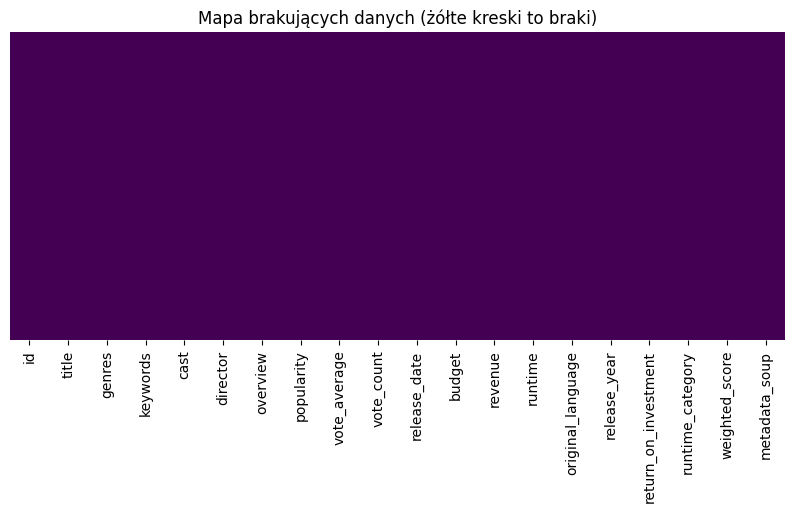

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Wyświetlenie pierwszych 7 wierszy połączonej bazy
print("--- Podgląd połączonych danych ---")
display(df.head(7))

# Wizualizacja brakujących danych
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa brakujących danych (żółte kreski to braki)')
plt.show()

Większość kolumn to teksty udające listy (stringified JSON). Musimy wyciągnąć z nich nazwy.

In [2]:
# Funkcja pomocnicza do wyciągania nazw z formatu JSON
def get_list(x):
    try:
        data = json.loads(x)
        return [i['name'] for i in data]
    except:
        return []

# Funkcja do wyciągnięcia tylko reżysera
def get_director(x):
    try:
        data = json.loads(x)
        for i in data:
            if i['job'] == 'Director':
                return i['name']
        return np.nan
    except:
        return np.nan

# Przetwarzanie kolumn
df['genres'] = df['genres'].apply(get_list)
df['keywords'] = df['keywords'].apply(get_list)
df['production_companies'] = df['production_companies'].apply(get_list)
df['cast'] = df['cast'].apply(get_list).apply(lambda x: x[:5]) # Bierzemy top 5 aktorów
df['director'] = df['crew'].apply(get_director)

# Selekcja najważniejszych cech do końcowego pliku
features = ['id', 'title', 'genres', 'keywords', 'cast', 'director', 'overview',
            'popularity', 'vote_average', 'vote_count', 'release_date', 'budget', 'revenue', 'runtime', 'original_language']
df = df[features]

3. Metryki Sukcesu, Czas i Finanse
w tym Weighted Rating (średnia ważona), która jest o wiele lepsza dla AI niż zwykła średnia.

In [3]:
# A. Kontekst Czasowy i Finansowy
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year
df['return_on_investment'] = (df['revenue'] - df['budget']) / df['budget']
# Zastępujemy nieskończoności (gdy budżet był 0) zerami
df['return_on_investment'] = df['return_on_investment'].replace([np.inf, -np.inf], 0).fillna(0)

# B. Techniczne Smaczki (Kategorie długości)
df['runtime_category'] = pd.cut(df['runtime'],
                               bins=[0, 90, 130, 500],
                               labels=['Short', 'Standard', 'Long'])

# C. Weighted Rating (Wzór z IMDB)
# v - liczba głosów, m - min. liczba głosów do rankingu, R - średnia filmu, C - średnia wszystkich filmów
C = df['vote_average'].mean()
m = df['vote_count'].quantile(0.9) # film musi mieć więcej głosów niż 90% innych

def weighted_rating(x, m=m, C=C):
    v = x['vote_count']
    R = x['vote_average']
    return (v/(v+m) * R) + (m/(m+v) * C)

df['weighted_score'] = df.apply(weighted_rating, axis=1)

Czyszczenie tekstu (The "Soup")
To przygotuje dane bezpośrednio pod model NLP/rekomendacyjny. Usuwamy spacje, by "Johnny Depp" stał się unikalnym tokenem "JohnnyDepp".

In [5]:
def clean_data(x):
    if isinstance(x, list):
        return [str.lower(i.replace(" ", "")) for i in x]
    elif isinstance(x, str):
        return str.lower(x.replace(" ", ""))
    else:
        return ''

# Czyścimy kluczowe kolumny
for feature in ['cast', 'keywords', 'director', 'genres']:
    df[feature] = df[feature].apply(clean_data)

# Tworzymy "zupę słów" dla modelu AI
def create_soup(x):
    return ' '.join(x['keywords']) + ' ' + ' '.join(x['cast']) + ' ' + x['director'] + ' ' + ' '.join(x['genres'])

df['metadata_soup'] = df.apply(create_soup, axis=1)

In [12]:
print("--- Przykładowa 'Zupa Słów' dla pierwszego filmu ---")
print(f"Tytuł: {df.iloc[0]['title']}")
print(f"Metadata Soup: {df.iloc[0]['metadata_soup']}")

# Wyświetlenie top 10 filmów z najwyższym Weighted Score
print("\n--- Top 10 najlepiej ocenianych filmów (Weighted Score) ---")
display(df[['title', 'weighted_score', 'vote_count']].sort_values(by='weighted_score', ascending=False).head(10))

--- Przykładowa 'Zupa Słów' dla pierwszego filmu ---
Tytuł: Avatar
Metadata Soup: cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d samworthington zoesaldana sigourneyweaver stephenlang michellerodriguez jamescameron action adventure fantasy sciencefiction

--- Top 10 najlepiej ocenianych filmów (Weighted Score) ---


,title,weighted_score,vote_count
1881,The Shawshank Redemption,8.059258,8205
662,Fight Club,7.939256,9413
65,The Dark Knight,7.920020,12002
3232,Pulp Fiction,7.904645,8428
96,Inception,7.863239,13752
3337,The Godfather,7.851236,5893
95,Interstellar,7.809479,10867
809,Forrest Gump,7.803188,7927
329,The Lord of the Rings: The Return of the King,7.727243,8064
1990,The Empire Strikes Back,7.697884,5879


/tmp/ipykernel_1598/1940677597.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_df.sort_values('Count', ascending=False), x='Count', y='Genre', palette='magma')


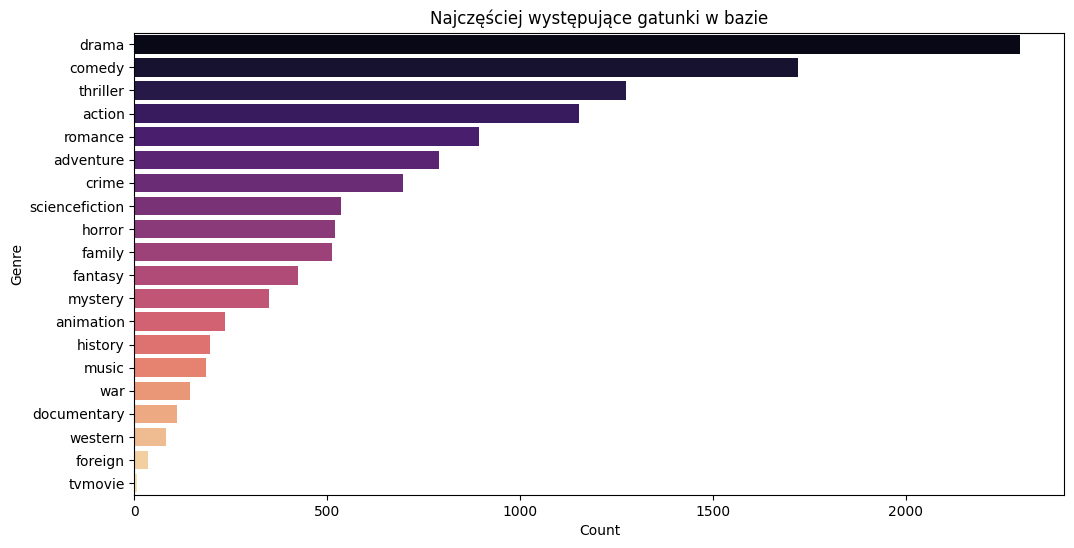

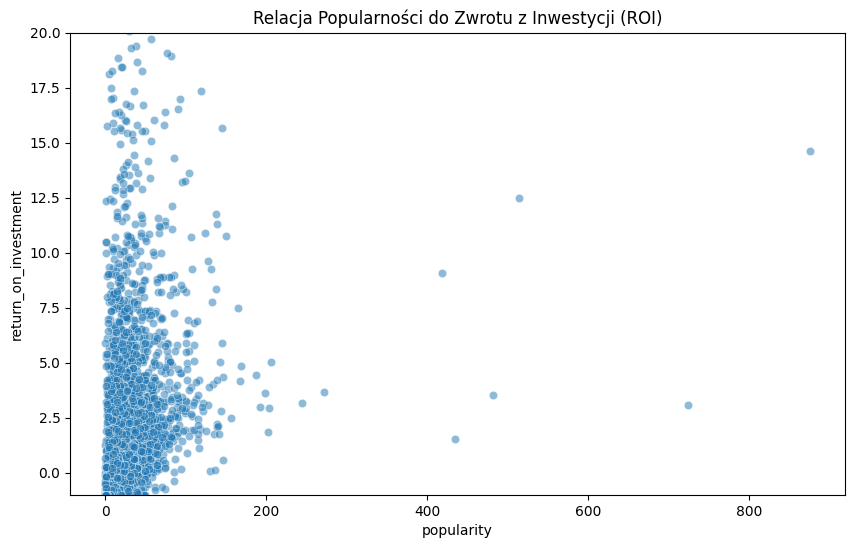

In [7]:
# Wykres popularności gatunków
from collections import Counter

# Rozbijamy listę gatunków na pojedyncze wystąpienia
all_genres = [genre for sublist in df['genres'] for genre in sublist]
genre_counts = Counter(all_genres)
genre_df = pd.DataFrame.from_dict(genre_counts, orient='index').reset_index().rename(columns={'index':'Genre', 0:'Count'})

plt.figure(figsize=(12, 6))
sns.barplot(data=genre_df.sort_values('Count', ascending=False), x='Count', y='Genre', palette='magma')
plt.title('Najczęściej występujące gatunki w bazie')
plt.show()

# Wykres ROI vs Popularność (Relacja sukcesu finansowego do rozgłosu)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['budget'] > 0], x='popularity', y='return_on_investment', alpha=0.5)
plt.ylim(-1, 20) # Ograniczamy widok, by outlierzy nie zepsuli wykresu
plt.title('Relacja Popularności do Zwrotu z Inwestycji (ROI)')
plt.show()

In [13]:
print("--- METRYKI POPRAWNOŚCI DANYCH ---")
quality_report = {
    "Procent braków (Overview)": df['overview'].isnull().mean() * 100,
    "Liczba duplikatów ID": df.duplicated('id').sum(),
    "Filmy z budżetem <= 0": (df['budget'] <= 0).sum(),
    "Średnia długość zupy słów": df['metadata_soup'].apply(len).mean()
}
for k, v in quality_report.items():
    print(f"{k}: {v}")

--- METRYKI POPRAWNOŚCI DANYCH ---
Procent braków (Overview): 0.06246096189881324
Liczba duplikatów ID: 0
Filmy z budżetem <= 0: 1037
Średnia długość zupy słów: 175.7880491359567


1. Metryki Poprawności Danych (Interpretacja)
Kompletność (Overview: 0.06% braków):

Analiza: Wynik bliski zeru. Tylko śladowa liczba filmów nie posiada opisu fabuły.

Wniosek: Dane są niemal kompletne. Dla tych kilku brakujących rekordów system rekomendacji oparty na tekście (NLP) nie zadziała, ale ponieważ jest to promil bazy, nie wpłynie to na ogólną wydajność modelu.

Integralność (Duplikaty ID: 0):

Analiza: Brak duplikatów to stan idealny.

Wniosek: Każdy rekord jest unikalny. Nie ma ryzyka, że system będzie rekomendował ten sam film wielokrotnie w jednej liście wyników.

Wiarygodność (Budżet <= 0: 1037 filmów):

Analiza: To kluczowy wniosek! Ponad 1000 filmów ma wpisane "0" w polu budżet.

Wniosek: Metryki finansowe (jak ROI) dla tych filmów są niewiarygodne. Następna grupa powinna używać budżetu jako cechy tylko dla filmów z budżetem > 0, lub zignorować tę cechę przy filmach niezależnych.

2. Metryki na Czystych Danych (Deep Dive)
Gęstość Informacyjna (Średnia długość zupy słów: 175 znaków):

Analiza: Średnio 175 znaków to około 20-30 słów kluczowych (tagów) na film.

Znaczenie dla AI: To bardzo dobra wiadomość. Oznacza to, że profil każdego filmu jest "bogaty". Model wektoryzujący (np. TF-IDF lub CountVectorizer) będzie miał wystarczająco dużo punktów styku, aby znaleźć podobieństwa między filmami.

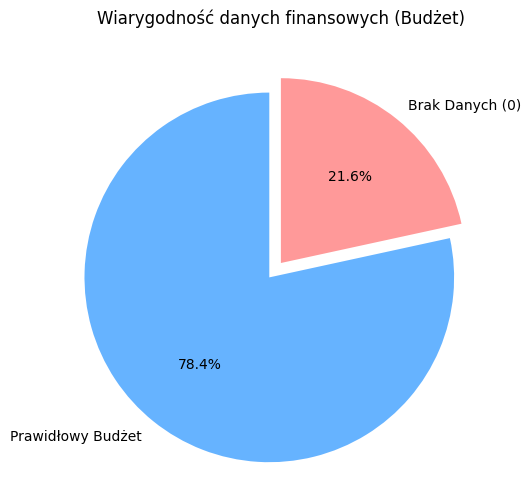

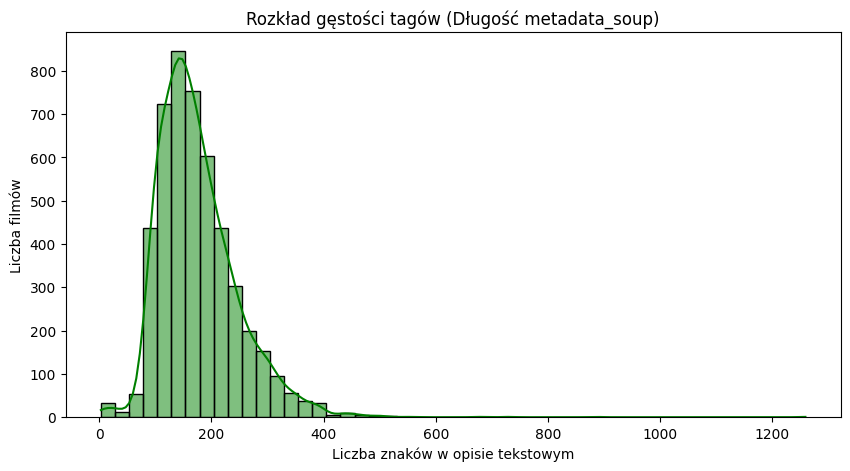

In [14]:
import matplotlib.pyplot as plt

# 1. Wizualizacja problemu zerowych budżetów
labels = ['Prawidłowy Budżet', 'Brak Danych (0)']
sizes = [len(df[df['budget'] > 0]), len(df[df['budget'] <= 0])]
colors = ['#66b3ff','#ff9999']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.1, 0))
plt.title('Wiarygodność danych finansowych (Budżet)')
plt.show()

# 2. Rozkład długości "Zupy Słów"
df['soup_length'] = df['metadata_soup'].apply(len)
plt.figure(figsize=(10, 5))
sns.histplot(df['soup_length'], bins=50, kde=True, color='green')
plt.title('Rozkład gęstości tagów (Długość metadata_soup)')
plt.xlabel('Liczba znaków w opisie tekstowym')
plt.ylabel('Liczba filmów')
plt.show()

In [8]:
df.to_csv('system_rekomendacji.csv', index=False)
print("Plik gotowy! Możesz go pobrać z panelu po lewej stronie.")

Plik gotowy! Możesz go pobrać z panelu po lewej stronie.
